# B2B Lead Scoring: Comprehensive Data Cleaning & Quality Assessment

**Objective:** Clean and standardize the raw lead dataset while identifying data quality issues.

**Business Context:** Real-world CRM data contains two types of missing values:
1. **Expected missing data** - Users/sales haven't completed fields ('Select' placeholders)
2. **Data quality issues** - System bugs allowing NaN values that shouldn't exist

**Key Insight:** Distinguishing between these reveals both:
- Patterns in user/sales behavior (for modeling)
- Systemic data pipeline issues (for engineering fixes)

**Why This Matters:** 
- Clean data = Better model accuracy
- Data quality analysis = Process improvements
- Understanding missing data patterns = Better features

## 1. Setup & Load Raw Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
# Load raw data
df_raw = pd.read_csv('../data/Leads.csv')

print(f"Raw dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Raw dataset loaded: 9,240 rows × 37 columns
Memory usage: 14.72 MB


In [3]:
# Quick peek at the data
print("=" * 80)
print("SAMPLE OF RAW DATA (First 3 rows)")
print("=" * 80)
df_raw.head(3)

SAMPLE OF RAW DATA (First 3 rows)


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened


## 2. Identify Data Quality Issues

We need to distinguish between:
- **'Select' placeholders** → Expected missing (user/sales didn't fill)
- **NaN values** → Data quality issues (should be prevented by validation)

In [4]:
# Check for 'Select' placeholder values
print("=" * 80)
print("'SELECT' PLACEHOLDERS (Expected Missing Data)")
print("=" * 80)

select_counts = {}
for col in df_raw.columns:
    if df_raw[col].dtype == 'object':
        select_count = (df_raw[col] == 'Select').sum()
        if select_count > 0:
            select_counts[col] = select_count
            pct = (select_count / len(df_raw)) * 100
            print(f"{col:45} → {select_count:5,} ({pct:5.1f}%)")

print(f"\n✓ Total columns with 'Select' values: {len(select_counts)}")

'SELECT' PLACEHOLDERS (Expected Missing Data)
Specialization                                → 1,942 ( 21.0%)
How did you hear about X Education            → 5,043 ( 54.6%)
Lead Profile                                  → 4,146 ( 44.9%)
City                                          → 2,249 ( 24.3%)

✓ Total columns with 'Select' values: 4


In [5]:
# Check for NaN values (data quality issues)
print("=" * 80)
print("NaN VALUES (Data Quality Issues - Should Not Exist)")
print("=" * 80)

missing_summary = pd.DataFrame({
    'Column': df_raw.columns,
    'NaN_Count': df_raw.isnull().sum(),
    'NaN_Percentage': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
}).sort_values('NaN_Percentage', ascending=False)

missing_summary = missing_summary[missing_summary['NaN_Count'] > 0]

if len(missing_summary) > 0:
    print(f"\n⚠️  Found {len(missing_summary)} columns with NaN values:\n")
    print(missing_summary.to_string(index=False))
else:
    print("\n✓ No NaN values found")

NaN VALUES (Data Quality Issues - Should Not Exist)

⚠️  Found 17 columns with NaN values:

                                       Column  NaN_Count  NaN_Percentage
                                 Lead Quality       4767           51.59
                  Asymmetrique Activity Index       4218           45.65
                   Asymmetrique Profile Score       4218           45.65
                  Asymmetrique Activity Score       4218           45.65
                   Asymmetrique Profile Index       4218           45.65
                                         Tags       3353           36.29
                                 Lead Profile       2709           29.32
What matters most to you in choosing a course       2709           29.32
              What is your current occupation       2690           29.11
                                      Country       2461           26.63
           How did you hear about X Education       2207           23.89
                               S

## 3. Deep Inspection: Understanding the Data

Before cleaning, let's examine what values actually exist in problematic columns.

In [6]:
# Inspect key categorical columns
print("=" * 80)
print("INSPECTING KEY COLUMNS (Before Cleaning)")
print("=" * 80)

columns_to_inspect = [
    'Specialization',
    'How did you hear about X Education', 
    'Lead Profile',
    'City',
    'Country',
    'What is your current occupation',
    'What matters most to you in choosing a course',
    'Tags',
    'Lead Quality'
]

for col in columns_to_inspect:
    if col in df_raw.columns:
        print(f"\n{'='*80}")
        print(f"COLUMN: {col}")
        print(f"{'='*80}")
        
        value_counts = df_raw[col].value_counts(dropna=False)
        total = len(df_raw)
        
        print(f"\nTop 10 values:")
        print(f"{'Value':<45} {'Count':>8} {'%':>8}")
        print("-" * 65)
        
        for val, count in value_counts.head(10).items():
            pct = (count / total) * 100
            val_str = str(val)[:42] + '...' if len(str(val)) > 45 else str(val)
            print(f"{val_str:<45} {count:>8,} {pct:>7.1f}%")
        
        n_unique = df_raw[col].nunique(dropna=False)
        print(f"\n→ Total unique values: {n_unique}")
        
        # Highlight issues
        select_count = (df_raw[col] == 'Select').sum()
        nan_count = df_raw[col].isna().sum()
        
        if select_count > 0:
            print(f"📝 'Select' placeholders: {select_count:,} ({select_count/total*100:.1f}%) - User/sales didn't fill")
        if nan_count > 0:
            print(f"⚠️  NaN values: {nan_count:,} ({nan_count/total*100:.1f}%) - DATA QUALITY ISSUE")

INSPECTING KEY COLUMNS (Before Cleaning)

COLUMN: Specialization

Top 10 values:
Value                                            Count        %
-----------------------------------------------------------------
Select                                           1,942    21.0%
nan                                              1,438    15.6%
Finance Management                                 976    10.6%
Human Resource Management                          848     9.2%
Marketing Management                               838     9.1%
Operations Management                              503     5.4%
Business Administration                            403     4.4%
IT Projects Management                             366     4.0%
Supply Chain Management                            349     3.8%
Banking, Investment And Insurance                  338     3.7%

→ Total unique values: 20
📝 'Select' placeholders: 1,942 (21.0%) - User/sales didn't fill
⚠️  NaN values: 1,438 (15.6%) - DATA QUALITY ISSUE

COLUMN

In [7]:
# Inspect behavioral metrics
print("=" * 80)
print("BEHAVIORAL METRICS INSPECTION")
print("=" * 80)

behavioral_cols = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

for col in behavioral_cols:
    if col in df_raw.columns:
        print(f"\n{col}:")
        print(f"  Count: {df_raw[col].count():,}")
        print(f"  Missing: {df_raw[col].isnull().sum():,} ({df_raw[col].isnull().sum()/len(df_raw)*100:.1f}%)")
        print(f"  Min: {df_raw[col].min()}")
        print(f"  Max: {df_raw[col].max()}")
        print(f"  Mean: {df_raw[col].mean():.2f}")
        print(f"  Median: {df_raw[col].median():.2f}")
        print(f"  Zeros: {(df_raw[col] == 0).sum():,} ({(df_raw[col] == 0).sum()/len(df_raw)*100:.1f}%)")

BEHAVIORAL METRICS INSPECTION

TotalVisits:
  Count: 9,103
  Missing: 137 (1.5%)
  Min: 0.0
  Max: 251.0
  Mean: 3.45
  Median: 3.00
  Zeros: 2,189 (23.7%)

Total Time Spent on Website:
  Count: 9,240
  Missing: 0 (0.0%)
  Min: 0
  Max: 2272
  Mean: 487.70
  Median: 248.00
  Zeros: 2,193 (23.7%)

Page Views Per Visit:
  Count: 9,103
  Missing: 137 (1.5%)
  Min: 0.0
  Max: 55.0
  Mean: 2.36
  Median: 2.00
  Zeros: 2,189 (23.7%)


In [8]:
# Check behavioral metrics missing pattern
print("=" * 80)
print("BEHAVIORAL METRICS MISSING VALUE PATTERN")
print("=" * 80)

missing_visits = df_raw[df_raw['TotalVisits'].isna()]

print(f"\nRows where TotalVisits is missing: {len(missing_visits)}")
print(f"\nFor these {len(missing_visits)} rows:")
print(f"  - Also missing Page Views Per Visit: {missing_visits['Page Views Per Visit'].isna().sum()}")
print(f"  - Missing Total Time Spent: {missing_visits['Total Time Spent on Website'].isna().sum()}")
print(f"  - Have Total Time Spent = 0: {(missing_visits['Total Time Spent on Website'] == 0).sum()}")
print(f"  - Have Total Time Spent > 0: {(missing_visits['Total Time Spent on Website'] > 0).sum()}")

# Calculate reference values for imputation
has_data = df_raw[df_raw['TotalVisits'].notna() & (df_raw['TotalVisits'] > 0)]
if len(has_data) > 0:
    median_time_per_visit = (has_data['Total Time Spent on Website'] / has_data['TotalVisits']).median()
    median_pages_per_visit = has_data['Page Views Per Visit'].median()
    
    print(f"\n📊 Reference Values for Imputation:")
    print(f"  Median time per visit: {median_time_per_visit:.2f} seconds")
    print(f"  Median pages per visit: {median_pages_per_visit:.2f}")

BEHAVIORAL METRICS MISSING VALUE PATTERN

Rows where TotalVisits is missing: 137

For these 137 rows:
  - Also missing Page Views Per Visit: 137
  - Missing Total Time Spent: 0
  - Have Total Time Spent = 0: 0
  - Have Total Time Spent > 0: 137

📊 Reference Values for Imputation:
  Median time per visit: 119.22 seconds
  Median pages per visit: 3.00


## 4. Key Business Insights from Missing Data Patterns

In [9]:
# Check if missing data correlates with conversion
print("=" * 80)
print("FORM COMPLETION ANALYSIS - CRITICAL INSIGHT")
print("=" * 80)

# Identify leads missing key profile fields
missing_profile = df_raw['Lead Profile'].isna() | (df_raw['Lead Profile'] == 'Select')
missing_matters = df_raw['What matters most to you in choosing a course'].isna()
missing_occupation = df_raw['What is your current occupation'].isna()

missing_all_three = missing_profile & missing_matters & missing_occupation
has_all_three = ~(missing_profile | missing_matters | missing_occupation)

print(f"\nLeads missing ALL 3 profile fields: {missing_all_three.sum():,} ({missing_all_three.sum()/len(df_raw)*100:.1f}%)")
print(f"Leads with ALL 3 profile fields: {has_all_three.sum():,} ({has_all_three.sum()/len(df_raw)*100:.1f}%)")

print(f"\n💡 CONVERSION RATES:")
conv_missing = df_raw[missing_all_three]['Converted'].mean() * 100
conv_complete = df_raw[has_all_three]['Converted'].mean() * 100
print(f"  Missing all 3 fields:  {conv_missing:5.1f}%")
print(f"  Has all 3 fields:      {conv_complete:5.1f}%")
print(f"  Conversion difference: {conv_complete - conv_missing:5.1f}% (or {conv_complete/conv_missing:.1f}x higher)")

print(f"\n🎯 KEY INSIGHT: Form completion is a STRONG conversion predictor!")

FORM COMPLETION ANALYSIS - CRITICAL INSIGHT

Leads missing ALL 3 profile fields: 2,690 (29.1%)
Leads with ALL 3 profile fields: 2,385 (25.8%)

💡 CONVERSION RATES:
  Missing all 3 fields:   13.8%
  Has all 3 fields:       62.9%
  Conversion difference:  49.1% (or 4.6x higher)

🎯 KEY INSIGHT: Form completion is a STRONG conversion predictor!


## 5. Data Cleaning Strategy

Based on our analysis, here's our cleaning approach:

### **Type 1: 'Select' Placeholders (Expected Missing)**
- User/sales didn't complete field
- Replace with descriptive value: "Awaiting User Input"

### **Type 2: NaN Values (Data Quality Issues)**
- Should not exist with proper validation
- Flag as "Data Error" for analysis
- Document for engineering fixes

### **Type 3: Behavioral Metrics (Smart Imputation)**
- Use relationships between metrics
- If Time Spent > 0 but Visits missing → Calculate from median
- If Time Spent = 0 → Visits = 0

### **Type 4: Derived Features**
- Form completion score
- Data quality flags
- Action status categories

## 6. Execute Cleaning

In [10]:
# Create a copy for cleaning
df_clean = df_raw.copy()

print("Starting cleaning process...")
print(f"Shape: {df_clean.shape}")

Starting cleaning process...
Shape: (9240, 37)


### 6.1. Clean User-Provided Fields

In [11]:
print("=" * 80)
print("CLEANING STEP 1: User-Provided Fields")
print("=" * 80)

# Specialization
if 'Specialization' in df_clean.columns:
    select_count = (df_clean['Specialization'] == 'Select').sum()
    nan_count = df_clean['Specialization'].isna().sum()
    
    df_clean['Specialization'] = df_clean['Specialization'].replace('Select', 'Not Specified')
    df_clean['Specialization'] = df_clean['Specialization'].fillna('Data Error')
    
    print(f"\nSpecialization:")
    print(f"  'Select' → 'Not Specified': {select_count:,}")
    print(f"  NaN → 'Data Error': {nan_count:,}")

# How did you hear about X Education
if 'How did you hear about X Education' in df_clean.columns:
    select_count = (df_clean['How did you hear about X Education'] == 'Select').sum()
    nan_count = df_clean['How did you hear about X Education'].isna().sum()
    
    df_clean['How did you hear about X Education'] = df_clean['How did you hear about X Education'].replace('Select', 'Not Specified')
    df_clean['How did you hear about X Education'] = df_clean['How did you hear about X Education'].fillna('Data Error')
    
    print(f"\nHow did you hear about X Education:")
    print(f"  'Select' → 'Not Specified': {select_count:,}")
    print(f"  NaN → 'Data Error': {nan_count:,}")

# City
if 'City' in df_clean.columns:
    select_count = (df_clean['City'] == 'Select').sum()
    nan_count = df_clean['City'].isna().sum()
    
    df_clean['City'] = df_clean['City'].replace('Select', 'Not Specified')
    df_clean['City'] = df_clean['City'].fillna('Data Error')
    
    print(f"\nCity:")
    print(f"  'Select' → 'Not Specified': {select_count:,}")
    print(f"  NaN → 'Data Error': {nan_count:,}")

# Country (only NaN, no 'Select')
if 'Country' in df_clean.columns:
    nan_count = df_clean['Country'].isna().sum()
    df_clean['Country'] = df_clean['Country'].fillna('Data Error')
    print(f"\nCountry:")
    print(f"  NaN → 'Data Error': {nan_count:,}")

# What is your current occupation
if 'What is your current occupation' in df_clean.columns:
    nan_count = df_clean['What is your current occupation'].isna().sum()
    df_clean['What is your current occupation'] = df_clean['What is your current occupation'].fillna('Data Error')
    print(f"\nWhat is your current occupation:")
    print(f"  NaN → 'Data Error': {nan_count:,}")

# What matters most
if 'What matters most to you in choosing a course' in df_clean.columns:
    nan_count = df_clean['What matters most to you in choosing a course'].isna().sum()
    df_clean['What matters most to you in choosing a course'] = df_clean['What matters most to you in choosing a course'].fillna('Data Error')
    print(f"\nWhat matters most to you in choosing a course:")
    print(f"  NaN → 'Data Error': {nan_count:,}")

print(f"\n✓ User-provided fields cleaned")

CLEANING STEP 1: User-Provided Fields

Specialization:
  'Select' → 'Not Specified': 1,942
  NaN → 'Data Error': 1,438

How did you hear about X Education:
  'Select' → 'Not Specified': 5,043
  NaN → 'Data Error': 2,207

City:
  'Select' → 'Not Specified': 2,249
  NaN → 'Data Error': 1,420

Country:
  NaN → 'Data Error': 2,461

What is your current occupation:
  NaN → 'Data Error': 2,690

What matters most to you in choosing a course:
  NaN → 'Data Error': 2,709

✓ User-provided fields cleaned


### 6.2. Clean Sales/System Fields

In [12]:
print("=" * 80)
print("CLEANING STEP 2: Sales/System Fields")
print("=" * 80)

# Lead Profile
if 'Lead Profile' in df_clean.columns:
    select_count = (df_clean['Lead Profile'] == 'Select').sum()
    nan_count = df_clean['Lead Profile'].isna().sum()
    
    # 'Select' = awaiting categorization, NaN = data error
    df_clean['Lead Profile'] = df_clean['Lead Profile'].replace('Select', 'To Be Determined')
    df_clean['Lead Profile'] = df_clean['Lead Profile'].fillna('Data Error')
    
    # Create flags
    df_clean['has_lead_profile'] = (~df_clean['Lead Profile'].isin(['To Be Determined', 'Data Error'])).astype(int)
    df_clean['lead_profile_data_error'] = (df_clean['Lead Profile'] == 'Data Error').astype(int)
    
    print(f"\nLead Profile:")
    print(f"  'Select' → 'To Be Determined': {select_count:,}")
    print(f"  NaN → 'Data Error': {nan_count:,}")
    print(f"  ✓ Created flags: has_lead_profile, lead_profile_data_error")

# Lead Quality
if 'Lead Quality' in df_clean.columns:
    nan_count = df_clean['Lead Quality'].isna().sum()
    
    df_clean['Lead Quality'] = df_clean['Lead Quality'].fillna('Data Error')
    
    # Create flags
    df_clean['has_quality_assessment'] = (df_clean['Lead Quality'] != 'Data Error').astype(int)
    df_clean['quality_data_error'] = (df_clean['Lead Quality'] == 'Data Error').astype(int)
    
    print(f"\nLead Quality:")
    print(f"  NaN → 'Data Error': {nan_count:,}")
    print(f"  ✓ Created flags: has_quality_assessment, quality_data_error")

print(f"\n✓ Sales/system fields cleaned")

CLEANING STEP 2: Sales/System Fields

Lead Profile:
  'Select' → 'To Be Determined': 4,146
  NaN → 'Data Error': 2,709
  ✓ Created flags: has_lead_profile, lead_profile_data_error

Lead Quality:
  NaN → 'Data Error': 4,767
  ✓ Created flags: has_quality_assessment, quality_data_error

✓ Sales/system fields cleaned


### 6.3. Clean Tags & Create Action Status

In [13]:
print("=" * 80)
print("CLEANING STEP 3: Tags & Action Status")
print("=" * 80)

if 'Tags' in df_clean.columns:
    # Handle NaN
    nan_count = df_clean['Tags'].isna().sum()
    df_clean['Tags'] = df_clean['Tags'].fillna('Data Error')
    
    print(f"\nTags: NaN → 'Data Error': {nan_count:,}")
    
    # Create simplified action status
    def get_action_status(tag):
        if pd.isna(tag) or tag == 'Data Error':
            return 'Not Contacted'
        
        # Active engagement
        elif tag in ['Will revert after reading the email', 'Ringing', 'Busy', 
                     'Still Thinking', 'In confusion whether part time or DLP']:
            return 'In Discussion'
        
        # Lost/Closed
        elif tag in ['Closed by Horizzon', 'Lost to EINS', 'Lost to Others', 
                     'switched off', 'Not doing further education']:
            return 'Lost'
        
        # Cannot reach
        elif tag in ['invalid number', 'wrong number given', 'number not provided', 
                     'opp hangup']:
            return 'Unreachable'
        
        # Not eligible
        elif tag in ['Already a student', 'Diploma holder (Not Eligible)', 
                     'Graduation in progress', 'University not recognized']:
            return 'Not Eligible'
        
        # Interested but timing/product issue
        elif tag in ['Interested in other courses', 'Interested in full time MBA', 
                     'Interested in Next batch', 'Shall take in the next coming month',
                     'Want to take admission but has financial problems']:
            return 'Interested - Wrong Timing'
        
        else:
            return 'Other'
    
    df_clean['action_status'] = df_clean['Tags'].apply(get_action_status)
    
    # Create flags
    df_clean['has_sales_contact'] = (df_clean['action_status'] != 'Not Contacted').astype(int)
    df_clean['tags_data_error'] = (df_clean['Tags'] == 'Data Error').astype(int)
    df_clean['already_student'] = (df_clean['Tags'] == 'Already a student').astype(int)
    
    print(f"\n✓ Created action_status with {df_clean['action_status'].nunique()} categories")
    print(f"✓ Created flags: has_sales_contact, tags_data_error, already_student")
    
    print(f"\nAction Status Distribution:")
    print(df_clean['action_status'].value_counts())

CLEANING STEP 3: Tags & Action Status

Tags: NaN → 'Data Error': 3,353

✓ Created action_status with 7 categories
✓ Created flags: has_sales_contact, tags_data_error, already_student

Action Status Distribution:
action_status
In Discussion                3472
Not Contacted                3353
Lost                          925
Not Eligible                  641
Interested - Wrong Timing     526
Unreachable                   190
Other                         133
Name: count, dtype: int64


### 6.4. Clean Behavioral Metrics (Smart Imputation)

In [14]:
print("=" * 80)
print("CLEANING STEP 4: Behavioral Metrics (Smart Imputation)")
print("=" * 80)

# Calculate reference values from clean data
has_visits = df_clean[(df_clean['TotalVisits'].notna()) & (df_clean['TotalVisits'] > 0)]
median_time_per_visit = (has_visits['Total Time Spent on Website'] / has_visits['TotalVisits']).median()
median_pages_per_visit = has_visits['Page Views Per Visit'].median()

print(f"\nReference values for imputation:")
print(f"  Median time per visit: {median_time_per_visit:.0f} seconds")
print(f"  Median pages per visit: {median_pages_per_visit:.1f}")

# Impute TotalVisits
missing_visits_mask = df_clean['TotalVisits'].isna()

# Case 1: Time spent > 0, estimate visits
time_spent_positive = (missing_visits_mask) & (df_clean['Total Time Spent on Website'] > 0)
imputed_visits = (df_clean.loc[time_spent_positive, 'Total Time Spent on Website'] / median_time_per_visit).round()
df_clean.loc[time_spent_positive, 'TotalVisits'] = imputed_visits

# Case 2: Time spent = 0, visits = 0
time_spent_zero = (missing_visits_mask) & (df_clean['Total Time Spent on Website'] == 0)
df_clean.loc[time_spent_zero, 'TotalVisits'] = 0

print(f"\nTotalVisits imputation:")
print(f"  Calculated from time spent: {time_spent_positive.sum()}")
print(f"  Set to 0 (no activity): {time_spent_zero.sum()}")

# Impute Page Views Per Visit
missing_pages_mask = df_clean['Page Views Per Visit'].isna()

# Case 1: Visits > 0, use median
visits_positive = (missing_pages_mask) & (df_clean['TotalVisits'] > 0)
df_clean.loc[visits_positive, 'Page Views Per Visit'] = median_pages_per_visit

# Case 2: Visits = 0, pages = 0
visits_zero = (missing_pages_mask) & (df_clean['TotalVisits'] == 0)
df_clean.loc[visits_zero, 'Page Views Per Visit'] = 0

print(f"\nPage Views Per Visit imputation:")
print(f"  Set to median: {visits_positive.sum()}")
print(f"  Set to 0 (no visits): {visits_zero.sum()}")

print(f"\n✓ Behavioral metrics imputed using intelligent logic")

CLEANING STEP 4: Behavioral Metrics (Smart Imputation)

Reference values for imputation:
  Median time per visit: 119 seconds
  Median pages per visit: 3.0

TotalVisits imputation:
  Calculated from time spent: 137
  Set to 0 (no activity): 0

Page Views Per Visit imputation:
  Set to median: 130
  Set to 0 (no visits): 7

✓ Behavioral metrics imputed using intelligent logic


### 6.5. Create Derived Features

In [15]:
print("=" * 80)
print("CLEANING STEP 5: Create Derived Features")
print("=" * 80)

# Form completion score (critical predictor)
df_clean['form_completion_score'] = 0

# Add points for each completed field
if 'Lead Profile' in df_clean.columns:
    df_clean['form_completion_score'] += (~df_clean['Lead Profile'].isin(['To Be Determined', 'Data Error', 'Not Specified'])).astype(int)

if 'What matters most to you in choosing a course' in df_clean.columns:
    df_clean['form_completion_score'] += (df_clean['What matters most to you in choosing a course'] != 'Data Error').astype(int)

if 'What is your current occupation' in df_clean.columns:
    df_clean['form_completion_score'] += (df_clean['What is your current occupation'] != 'Data Error').astype(int)

if 'Specialization' in df_clean.columns:
    df_clean['form_completion_score'] += (~df_clean['Specialization'].isin(['Not Specified', 'Data Error'])).astype(int)

if 'How did you hear about X Education' in df_clean.columns:
    df_clean['form_completion_score'] += (~df_clean['How did you hear about X Education'].isin(['Not Specified', 'Data Error'])).astype(int)

# Normalize to 0-1
df_clean['form_completion_score'] = df_clean['form_completion_score'] / 5

print("\n✓ Created form_completion_score (0-1 scale)")
print("\nForm Completion Score Distribution:")
print(df_clean['form_completion_score'].value_counts().sort_index())

print("\nConversion by Form Completion Score:")
print(df_clean.groupby('form_completion_score')['Converted'].agg(['count', 'mean']).round(3))

CLEANING STEP 5: Create Derived Features

✓ Created form_completion_score (0-1 scale)

Form Completion Score Distribution:
form_completion_score
0.0    1419
0.2     801
0.4    2058
0.6    1968
0.8    2475
1.0     519
Name: count, dtype: int64

Conversion by Form Completion Score:
                       count   mean
form_completion_score              
0.0                     1419  0.106
0.2                      801  0.166
0.4                     2058  0.394
0.6                     1968  0.332
0.8                     2475  0.589
1.0                      519  0.684


In [16]:
# Asymmetrique flags
if 'Asymmetrique Activity Score' in df_clean.columns:
    df_clean['has_asymmetrique_data'] = df_clean['Asymmetrique Activity Score'].notna().astype(int)
    print("\n✓ Created has_asymmetrique_data flag")
    print(f"  Leads with Asymmetrique data: {df_clean['has_asymmetrique_data'].sum():,}")
    print(f"  Leads without: {(df_clean['has_asymmetrique_data'] == 0).sum():,}")


✓ Created has_asymmetrique_data flag
  Leads with Asymmetrique data: 5,022
  Leads without: 4,218


## 7. Verification & Quality Checks

In [17]:
# Verify no 'Select' values remain
print("=" * 80)
print("VERIFICATION: Checking for remaining 'Select' values")
print("=" * 80)

remaining_selects = 0
for col in df_clean.select_dtypes(include='object').columns:
    count = (df_clean[col] == 'Select').sum()
    if count > 0:
        print(f"⚠️  {col}: {count} 'Select' values remaining")
        remaining_selects += count

if remaining_selects == 0:
    print("✓ No 'Select' values remaining - excellent!")
else:
    print(f"\n⚠️  Warning: {remaining_selects} 'Select' values still present")

VERIFICATION: Checking for remaining 'Select' values
✓ No 'Select' values remaining - excellent!


In [18]:
# Check remaining missing values
print("=" * 80)
print("VERIFICATION: Remaining Missing Values")
print("=" * 80)

missing_after = pd.DataFrame({
    'Column': df_clean.columns,
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Percentage': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
}).sort_values('Missing_Percentage', ascending=False)

missing_after = missing_after[missing_after['Missing_Count'] > 0]

if len(missing_after) > 0:
    print(f"\nColumns still with missing values ({len(missing_after)}):")
    print(missing_after.to_string(index=False))
    print("\nNote: Asymmetrique scores kept as NaN (numeric fields, handled with flags)")
else:
    print("\n✓ No missing values remaining!")

VERIFICATION: Remaining Missing Values

Columns still with missing values (6):
                     Column  Missing_Count  Missing_Percentage
Asymmetrique Activity Index           4218               45.65
 Asymmetrique Profile Index           4218               45.65
Asymmetrique Activity Score           4218               45.65
 Asymmetrique Profile Score           4218               45.65
              Last Activity            103                1.11
                Lead Source             36                0.39

Note: Asymmetrique scores kept as NaN (numeric fields, handled with flags)


In [19]:
# Summary comparison
print("=" * 80)
print("BEFORE vs AFTER CLEANING")
print("=" * 80)

print(f"\nRAW DATA:")
print(f"  Shape: {df_raw.shape}")
print(f"  Columns: {df_raw.shape[1]}")

print(f"\nCLEAN DATA:")
print(f"  Shape: {df_clean.shape}")
print(f"  Columns: {df_clean.shape[1]}")
print(f"  New features added: {df_clean.shape[1] - df_raw.shape[1]}")

new_features = set(df_clean.columns) - set(df_raw.columns)
print(f"\nNew features created:")
for feat in sorted(new_features):
    print(f"  - {feat}")

print(f"\n✓ Data cleaning complete!")

BEFORE vs AFTER CLEANING

RAW DATA:
  Shape: (9240, 37)
  Columns: 37

CLEAN DATA:
  Shape: (9240, 47)
  Columns: 47
  New features added: 10

New features created:
  - action_status
  - already_student
  - form_completion_score
  - has_asymmetrique_data
  - has_lead_profile
  - has_quality_assessment
  - has_sales_contact
  - lead_profile_data_error
  - quality_data_error
  - tags_data_error

✓ Data cleaning complete!


## 8. Data Quality Report

In [20]:
print("=" * 80)
print("DATA QUALITY ISSUES REPORT")
print("=" * 80)

print("\n🚨 CRITICAL DATA PIPELINE ISSUES IDENTIFIED:")
print("\nThe following fields have NaN values that should not exist:")
print("(These indicate bugs in form validation or API endpoints)\n")

quality_issues = [
    ('Lead Profile', 'lead_profile_data_error'),
    ('Lead Quality', 'quality_data_error'),
    ('Tags', 'tags_data_error')
]

for field, flag_col in quality_issues:
    if flag_col in df_clean.columns:
        count = df_clean[flag_col].sum()
        pct = (count / len(df_clean)) * 100
        print(f"  {field:30} → {count:5,} records ({pct:5.1f}%)")

print("\n" + "=" * 80)
print("RECOMMENDED ENGINEERING FIXES")
print("=" * 80)

recommendations = [
    "1. Add form validation to prevent NaN submissions",
    "2. Make critical fields mandatory (Lead Profile, Tags after sales contact)",
    "3. Add API validation to reject requests with NaN values",
    "4. Implement data quality monitoring dashboard",
    "5. Add automated alerts when NaN values are detected",
    "6. Create workflow reminders: Alert sales when 'Select' remains after X days",
    "7. Sales process: Require Lead Quality assessment before marking lead as contacted"
]

for rec in recommendations:
    print(f"  {rec}")

DATA QUALITY ISSUES REPORT

🚨 CRITICAL DATA PIPELINE ISSUES IDENTIFIED:

The following fields have NaN values that should not exist:
(These indicate bugs in form validation or API endpoints)

  Lead Profile                   → 2,709 records ( 29.3%)
  Lead Quality                   → 4,767 records ( 51.6%)
  Tags                           → 3,353 records ( 36.3%)

RECOMMENDED ENGINEERING FIXES
  1. Add form validation to prevent NaN submissions
  2. Make critical fields mandatory (Lead Profile, Tags after sales contact)
  3. Add API validation to reject requests with NaN values
  4. Implement data quality monitoring dashboard
  5. Add automated alerts when NaN values are detected
  6. Create workflow reminders: Alert sales when 'Select' remains after X days
  7. Sales process: Require Lead Quality assessment before marking lead as contacted


In [21]:
# Impact analysis
print("\n" + "=" * 80)
print("IMPACT OF DATA QUALITY ISSUES ON CONVERSION")
print("=" * 80)

if 'lead_profile_data_error' in df_clean.columns:
    clean_data = df_clean[df_clean['lead_profile_data_error'] == 0]
    error_data = df_clean[df_clean['lead_profile_data_error'] == 1]
    
    print(f"\nConversion rates:")
    print(f"  Clean data (no errors):  {clean_data['Converted'].mean()*100:5.1f}%")
    print(f"  Data with errors:        {error_data['Converted'].mean()*100:5.1f}%")
    
    if error_data['Converted'].mean() < clean_data['Converted'].mean():
        print(f"\n💡 Insight: Data quality issues correlate with lower conversion!")
        print(f"   This validates the need for engineering fixes.")


IMPACT OF DATA QUALITY ISSUES ON CONVERSION

Conversion rates:
  Clean data (no errors):   48.9%
  Data with errors:         13.7%

💡 Insight: Data quality issues correlate with lower conversion!
   This validates the need for engineering fixes.


## 9. Visualize Cleaning Results

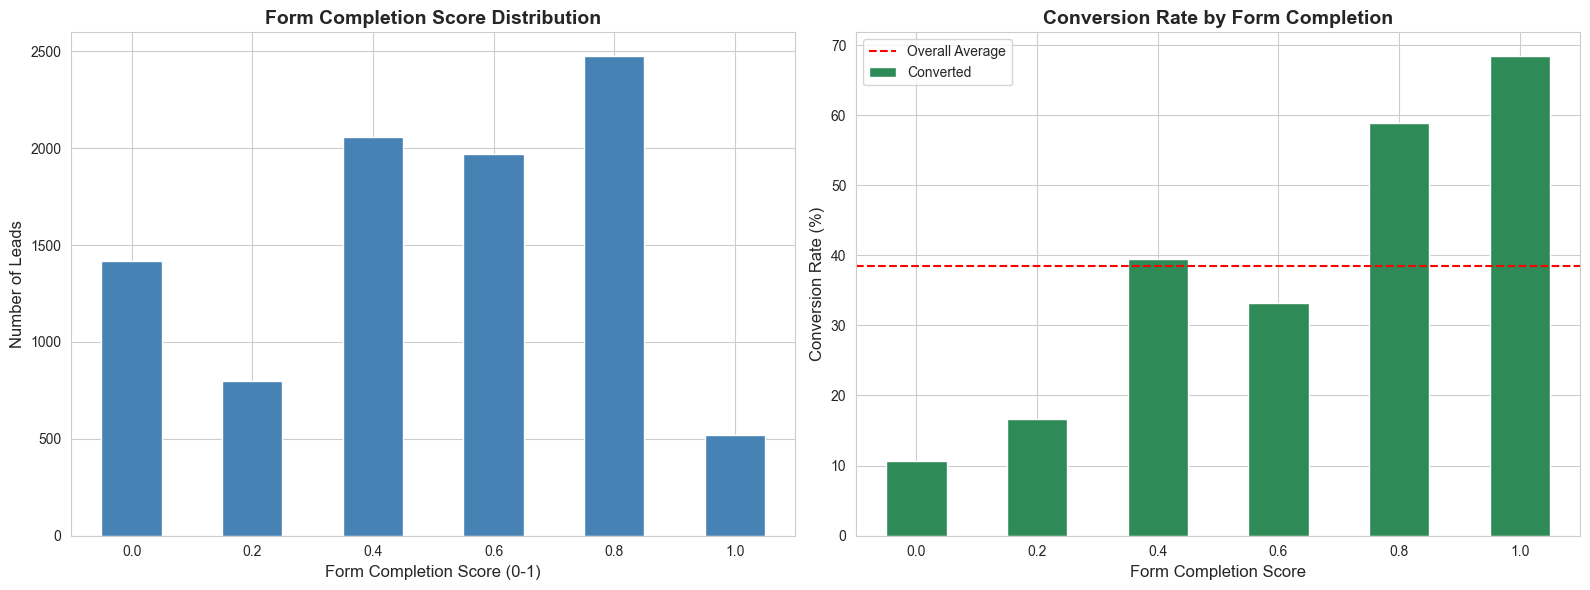


✓ Visualization saved to: visualizations/form_completion_analysis.png


In [22]:
# Visualize form completion impact
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Form completion score distribution
df_clean['form_completion_score'].value_counts().sort_index().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Form Completion Score Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Form Completion Score (0-1)', fontsize=12)
ax1.set_ylabel('Number of Leads', fontsize=12)
ax1.tick_params(axis='x', rotation=0)

# Conversion by form completion
completion_conv = df_clean.groupby('form_completion_score')['Converted'].mean() * 100
completion_conv.plot(kind='bar', ax=ax2, color='seagreen')
ax2.set_title('Conversion Rate by Form Completion', fontsize=14, fontweight='bold')
ax2.set_xlabel('Form Completion Score', fontsize=12)
ax2.set_ylabel('Conversion Rate (%)', fontsize=12)
ax2.tick_params(axis='x', rotation=0)
ax2.axhline(y=df_clean['Converted'].mean()*100, color='red', linestyle='--', label='Overall Average')
ax2.legend()

plt.tight_layout()
plt.savefig('../visualizations/form_completion_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to: visualizations/form_completion_analysis.png")

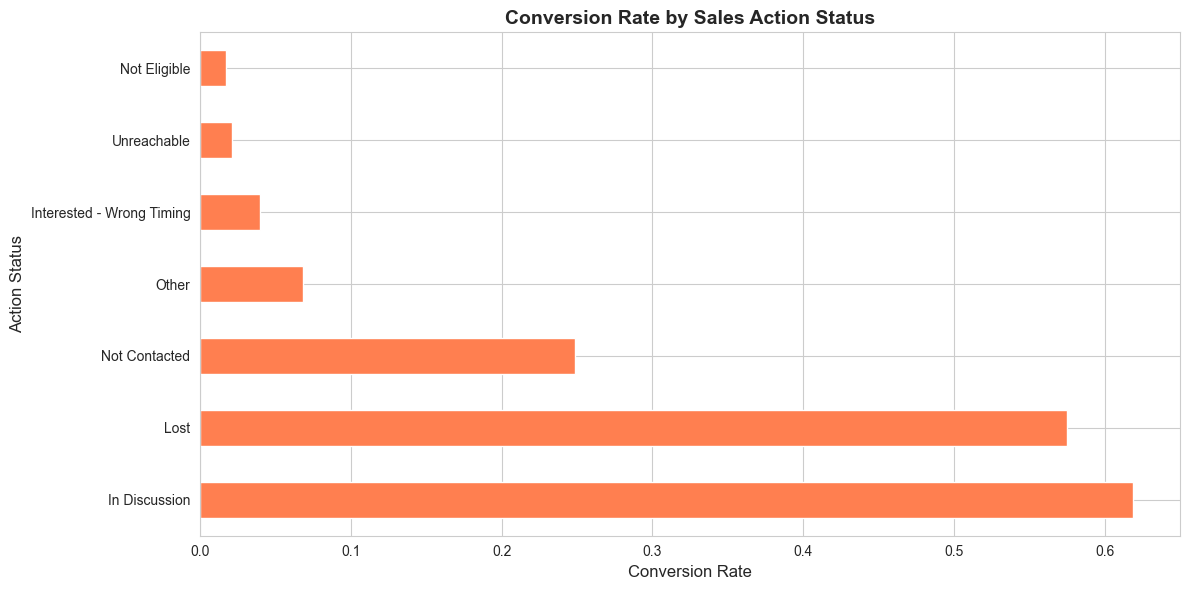

✓ Visualization saved to: visualizations/action_status_conversion.png


In [24]:
# Visualize action status impact
if 'action_status' in df_clean.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    status_conv = df_clean.groupby('action_status').agg({
        'Converted': ['count', 'mean']
    }).round(3)
    status_conv.columns = ['Count', 'Conversion_Rate']
    status_conv = status_conv.sort_values('Conversion_Rate', ascending=False)
    
    status_conv['Conversion_Rate'].plot(kind='barh', ax=ax, color='coral')
    ax.set_title('Conversion Rate by Sales Action Status', fontsize=14, fontweight='bold')
    ax.set_xlabel('Conversion Rate', fontsize=12)
    ax.set_ylabel('Action Status', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('../visualizations/action_status_conversion.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualization saved to: visualizations/action_status_conversion.png")

## 10. Save Clean Dataset

In [25]:
# Save cleaned data
output_path = '../data/Leads_clean.csv'
df_clean.to_csv(output_path, index=False)

print("=" * 80)
print("CLEAN DATASET SAVED")
print("=" * 80)
print(f"\nLocation: {output_path}")
print(f"Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"\n✓ Ready for exploratory analysis and modeling!")

CLEAN DATASET SAVED

Location: ../data/Leads_clean.csv
Shape: 9,240 rows × 47 columns

✓ Ready for exploratory analysis and modeling!


## 11. Summary & Key Insights

In [26]:
print("=" * 80)
print("DATA CLEANING SUMMARY & KEY INSIGHTS")
print("=" * 80)

summary = f"""
📋 CLEANING TRANSFORMATIONS:

1. USER-PROVIDED FIELDS:
   - Replaced 'Select' placeholders with 'Not Specified'
   - Flagged NaN values as 'Data Error' (pipeline bugs)
   - Fields: Specialization, City, How did you hear

2. SALES/SYSTEM FIELDS:
   - Distinguished 'Select' (to be determined) from NaN (data errors)
   - Created quality assessment flags
   - Fields: Lead Profile, Lead Quality, Tags

3. BEHAVIORAL METRICS:
   - Smart imputation using metric relationships
   - TotalVisits calculated from Time Spent / median time per visit
   - Page Views estimated from median for valid visits

4. DERIVED FEATURES:
   - form_completion_score (0-1): STRONG conversion predictor
   - action_status: Simplified sales engagement categories
   - Multiple data quality flags for analysis

🎯 KEY BUSINESS INSIGHTS:

1. Form Completion Impact:
   - Leads with complete forms: {df_clean[df_clean['form_completion_score'] == 1.0]['Converted'].mean()*100:.1f}% conversion
   - Leads with incomplete forms: {df_clean[df_clean['form_completion_score'] < 0.5]['Converted'].mean()*100:.1f}% conversion
   - Form completion itself is a conversion signal!

2. Data Quality Issues:
   - {df_clean['lead_profile_data_error'].sum():,} Lead Profile errors
   - {df_clean['quality_data_error'].sum():,} Lead Quality errors
   - {df_clean['tags_data_error'].sum():,} Tags errors
   - These require engineering fixes (form validation, API checks)

3. Sales Engagement:
   - {df_clean['has_sales_contact'].sum():,} leads contacted by sales
   - {(df_clean['has_sales_contact'] == 0).sum():,} leads not yet contacted
   - Action status provides clear engagement signals

💡 RECOMMENDATIONS:

FOR MODELING:
   - Use form_completion_score as key feature
   - Include data quality flags (signal of lead quality)
   - Action status provides sales engagement context
   - Consider excluding 'Already a student' ({df_clean['already_student'].sum()} leads)

FOR ENGINEERING:
   - Implement form validation to prevent NaN submissions
   - Add API validation layer
   - Create data quality monitoring dashboard
   - Alert sales team when forms remain incomplete

FOR SALES:
   - Prioritize leads with high form completion
   - Follow up on incomplete forms (easy conversion wins)
   - Ensure Lead Quality assessment is recorded properly

📁 OUTPUT:
   - Clean dataset: {output_path}
   - New features: {len(new_features)}
   - Ready for: Exploratory analysis → Feature engineering → Modeling

✅ NEXT STEP: Run Notebook 01 - Data Exploration
"""

print(summary)

DATA CLEANING SUMMARY & KEY INSIGHTS

📋 CLEANING TRANSFORMATIONS:

1. USER-PROVIDED FIELDS:
   - Replaced 'Select' placeholders with 'Not Specified'
   - Flagged NaN values as 'Data Error' (pipeline bugs)
   - Fields: Specialization, City, How did you hear

2. SALES/SYSTEM FIELDS:
   - Distinguished 'Select' (to be determined) from NaN (data errors)
   - Created quality assessment flags
   - Fields: Lead Profile, Lead Quality, Tags

3. BEHAVIORAL METRICS:
   - Smart imputation using metric relationships
   - TotalVisits calculated from Time Spent / median time per visit
   - Page Views estimated from median for valid visits

4. DERIVED FEATURES:
   - form_completion_score (0-1): STRONG conversion predictor
   - action_status: Simplified sales engagement categories
   - Multiple data quality flags for analysis

🎯 KEY BUSINESS INSIGHTS:

1. Form Completion Impact:
   - Leads with complete forms: 68.4% conversion
   - Leads with incomplete forms: 25.6% conversion
   - Form completion itse

## ✅ Cleaning Complete!

**What we accomplished:**
- Distinguished expected missing data from data quality issues
- Intelligently imputed behavioral metrics
- Created powerful derived features (form completion score)
- Identified systemic data pipeline bugs
- Generated actionable business recommendations

**The form completion insight alone is important because we can see that a good chuck of the users were not categorised correctly (having select or nan as value** - this means that this feedback needs to be passed to engineering to 1. filter and correct those issues. 2. block Select as a valid answer on user profile or form. 3. review the possible answers with sales to understand why they put nan instead of others.